In [1]:
import pandas as pd    
import numpy as np
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error      
from sklearn.preprocessing import StandardScaler

In [2]:
playerdf = pd.read_csv("C:\\Users\\hp\\Downloads\\Player.csv", index_col=0) 

In [3]:
 playerdf.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
-Andy Allanson,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [4]:
playerdf.shape

(322, 20)

In [5]:
playerdf.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 322 entries, -Andy Allanson to -Willie Wilson
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    obje

In [6]:
playerdf.isnull().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [7]:
playerdf.dropna(inplace=True)

In [8]:
playerdf.shape  

(263, 20)

In [9]:
pd.set_option('display.precision', 2)

In [10]:
playerdf.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00,263.00
mean,403.64,107.83,11.62,54.75,51.49,41.11,7.31,2657.54,722.19,69.24,361.22,330.42,260.27,290.71,118.76,8.59,535.93
std,147.31,45.13,8.76,25.54,25.88,21.72,4.79,2286.58,648.20,82.20,331.20,323.37,264.06,279.93,145.08,6.61,451.12
min,19.00,1.00,0.00,0.00,0.00,0.00,1.00,19.00,4.00,0.00,2.00,3.00,1.00,0.00,0.00,0.00,67.50
25%,282.50,71.50,5.00,33.50,30.00,23.00,4.00,842.50,212.00,15.00,105.50,95.00,71.00,113.50,8.00,3.00,190.00
50%,413.00,103.00,9.00,52.00,47.00,37.00,6.00,1931.00,516.00,40.00,250.00,230.00,174.00,224.00,45.00,7.00,425.00
75%,526.00,141.50,18.00,73.00,71.00,57.00,10.00,3890.50,1054.00,92.50,497.50,424.50,328.50,322.50,192.00,13.00,750.00
max,687.00,238.00,40.00,130.00,121.00,105.00,24.00,14053.00,4256.00,548.00,2165.00,1659.00,1566.00,1377.00,492.00,32.00,2460.00


In [11]:
 playerdf.League.value_counts()

League
A    139
N    124
Name: count, dtype: int64

In [12]:
playerdf.Division.value_counts()

Division
W    134
E    129
Name: count, dtype: int64

In [13]:
playerdf.NewLeague.value_counts()

NewLeague
A    141
N    122
Name: count, dtype: int64

In [14]:
dummyCol = pd.get_dummies(playerdf[['League', 'Division', 'NewLeague']])

In [15]:
dummyCol.head(3)

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
-Alan Ashby,False,True,False,True,False,True
-Alvin Davis,True,False,False,True,True,False
-Andre Dawson,False,True,True,False,False,True


In [16]:
dummyCol.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, -Alan Ashby to -Willie Wilson
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   League_A     263 non-null    bool 
 1   League_N     263 non-null    bool 
 2   Division_E   263 non-null    bool 
 3   Division_W   263 non-null    bool 
 4   NewLeague_A  263 non-null    bool 
 5   NewLeague_N  263 non-null    bool 
dtypes: bool(6)
memory usage: 3.6+ KB


In [17]:
XTemp = playerdf.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1)

In [18]:
X = pd.concat([XTemp, dummyCol[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)

In [19]:
X.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, -Alan Ashby to -Willie Wilson
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   AtBat        263 non-null    int64
 1   Hits         263 non-null    int64
 2   HmRun        263 non-null    int64
 3   Runs         263 non-null    int64
 4   RBI          263 non-null    int64
 5   Walks        263 non-null    int64
 6   Years        263 non-null    int64
 7   CAtBat       263 non-null    int64
 8   CHits        263 non-null    int64
 9   CHmRun       263 non-null    int64
 10  CRuns        263 non-null    int64
 11  CRBI         263 non-null    int64
 12  CWalks       263 non-null    int64
 13  PutOuts      263 non-null    int64
 14  Assists      263 non-null    int64
 15  Errors       263 non-null    int64
 16  League_N     263 non-null    bool 
 17  Division_W   263 non-null    bool 
 18  NewLeague_N  263 non-null    bool 
dtypes: bool(3), int64(16)
memory usage

In [20]:
 y = playerdf.Salary

In [21]:
y.head() 

-Alan Ashby          475.0
-Alvin Davis         480.0
-Andre Dawson        500.0
-Andres Galarraga     91.5
-Alfredo Griffin     750.0
Name: Salary, dtype: float64

In [22]:
alphas = 10**np.linspace(10,-2,100)*0.00001

In [23]:
 ridge = Ridge()  

In [24]:
coeffs = []

In [25]:
scaler = StandardScaler() 
for a in alphas: 
    ridge.set_params(alpha=a) 
    ridge.fit(scaler.fit_transform(X), y)
    coeffs.append(ridge.coef_) 

In [26]:
np.shape(coeffs)

(100, 19)

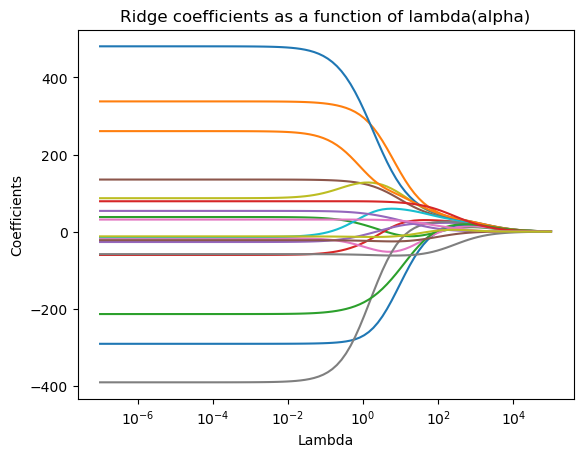

In [30]:
ax = plt.gca() 
ax.plot(alphas, coeffs) 
ax.set_xscale('log') 
plt.axis('tight') 
plt.xlabel('Lambda')
plt.ylabel('Coefficients') 
plt.title('Ridge coefficients as a function of lambda(alpha)')
plt.show() 

In [35]:
pd.set_option("display.precision", 6)


In [36]:
 X_train, X_test , y_train, y_test = model_selection.train_test_split(X,y, test_size=0.5, random_state=1)

In [37]:
def Ridge_Regression(alpha): 
    scaler = StandardScaler() 
    ridge = Ridge(alpha=alpha) 
    ridge.fit(scaler.fit_transform(X_train), y_train) 
    pred = ridge.predict(scaler.fit_transform(X_test)) 
    print(pd.Series(ridge.coef_, index=X.columns)) 
    print('Mean Squared Error: ',mean_squared_error(y_test, pred))

In [38]:
Ridge_Regression(0)

AtBat          -266.553048
Hits            197.706218
HmRun           -38.103182
Runs             -1.007996
RBI             103.119845
Walks            79.750209
Years            45.357697
CAtBat        -1399.811384
CHits          1426.954812
CHmRun          264.037977
CRuns            86.858781
CRBI           -211.142393
CWalks           42.533597
PutOuts         126.075563
Assists          65.816094
Errors          -38.313885
League_N         66.822855
Division_W      -56.870280
NewLeague_N     -40.962688
dtype: float64
Mean Squared Error:  117301.055033745


In [39]:
Ridge_Regression(4)

AtBat         -210.807322
Hits           193.076932
HmRun          -51.437368
Runs             1.624070
RBI             81.458917
Walks           94.582539
Years          -28.029476
CAtBat        -117.924364
CHits           91.159632
CHmRun          91.762010
CRuns          101.115450
CRBI           117.598963
CWalks         -38.434685
PutOuts        125.556071
Assists         25.559188
Errors         -18.518904
League_N        35.792050
Division_W     -60.245442
NewLeague_N    -18.650623
dtype: float64
Mean Squared Error:  104835.06228323371


In [40]:
 Ridge_Regression(100)

AtBat           3.911359
Hits           36.096360
HmRun           1.736680
Runs           19.611659
RBI            32.219132
Walks          43.972410
Years           8.496447
CAtBat         17.992839
CHits          32.545056
CHmRun         41.512925
CRuns          33.271936
CRBI           41.571334
CWalks         25.535833
PutOuts        75.761366
Assists        -2.475953
Errors         -0.792667
League_N        8.214298
Division_W    -41.608368
NewLeague_N     5.211955
dtype: float64
Mean Squared Error:  100357.25470322548


In [41]:
Ridge_Regression(10**10)

AtBat          2.526133e-06
Hits           2.826091e-06
HmRun          2.174902e-06
Runs           2.632138e-06
RBI            3.183658e-06
Walks          2.941154e-06
Years          2.478179e-06
CAtBat         3.213788e-06
CHits          3.432349e-06
CHmRun         3.435819e-06
CRuns          3.522298e-06
CRBI           3.602930e-06
CWalks         3.216811e-06
PutOuts        2.851209e-06
Assists       -4.856786e-08
Errors         1.736624e-07
League_N      -1.637144e-07
Division_W    -1.015188e-06
NewLeague_N   -1.325154e-07
dtype: float64
Mean Squared Error:  172862.2200557664


In [42]:
scaler = StandardScaler()

In [43]:
ridgecv = RidgeCV(alphas=alphas)

In [44]:
ridgecv.fit(scaler.fit_transform(X_train), y_train)

RidgeCV(alphas=array([1.00000000e+05, 7.56463328e+04, 5.72236766e+04, 4.32876128e+04,
       3.27454916e+04, 2.47707636e+04, 1.87381742e+04, 1.41747416e+04,
       1.07226722e+04, 8.11130831e+03, 6.13590727e+03, 4.64158883e+03,
       3.51119173e+03, 2.65608778e+03, 2.00923300e+03, 1.51991108e+03,
       1.14975700e+03, 8.69749003e+02, 6.57933225e+02, 4.97702356e+02,
       3.76493581e+02, 2.84803587e+0...
       6.13590727e-05, 4.64158883e-05, 3.51119173e-05, 2.65608778e-05,
       2.00923300e-05, 1.51991108e-05, 1.14975700e-05, 8.69749003e-06,
       6.57933225e-06, 4.97702356e-06, 3.76493581e-06, 2.84803587e-06,
       2.15443469e-06, 1.62975083e-06, 1.23284674e-06, 9.32603347e-07,
       7.05480231e-07, 5.33669923e-07, 4.03701726e-07, 3.05385551e-07,
       2.31012970e-07, 1.74752840e-07, 1.32194115e-07, 1.00000000e-07]))

In [45]:
ridgecv.alpha_ 

70.54802310718645

In [46]:
 scaler = StandardScaler()

In [47]:
 ridgecv = RidgeCV(alphas=alphas, cv=5)

In [48]:
ridgecv.fit(scaler.fit_transform(X_train), y_train)

RidgeCV(alphas=array([1.00000000e+05, 7.56463328e+04, 5.72236766e+04, 4.32876128e+04,
       3.27454916e+04, 2.47707636e+04, 1.87381742e+04, 1.41747416e+04,
       1.07226722e+04, 8.11130831e+03, 6.13590727e+03, 4.64158883e+03,
       3.51119173e+03, 2.65608778e+03, 2.00923300e+03, 1.51991108e+03,
       1.14975700e+03, 8.69749003e+02, 6.57933225e+02, 4.97702356e+02,
       3.76493581e+02, 2.84803587e+0...
       6.13590727e-05, 4.64158883e-05, 3.51119173e-05, 2.65608778e-05,
       2.00923300e-05, 1.51991108e-05, 1.14975700e-05, 8.69749003e-06,
       6.57933225e-06, 4.97702356e-06, 3.76493581e-06, 2.84803587e-06,
       2.15443469e-06, 1.62975083e-06, 1.23284674e-06, 9.32603347e-07,
       7.05480231e-07, 5.33669923e-07, 4.03701726e-07, 3.05385551e-07,
       2.31012970e-07, 1.74752840e-07, 1.32194115e-07, 1.00000000e-07]),
        cv=5)

In [49]:
 ridgecv.alpha_  

93.26033468832199

In [50]:
scaler = StandardScaler()

In [51]:
ridgecv = RidgeCV(alphas=alphas, cv=10)

In [52]:
ridgecv.fit(scaler.fit_transform(X_train), y_train)

RidgeCV(alphas=array([1.00000000e+05, 7.56463328e+04, 5.72236766e+04, 4.32876128e+04,
       3.27454916e+04, 2.47707636e+04, 1.87381742e+04, 1.41747416e+04,
       1.07226722e+04, 8.11130831e+03, 6.13590727e+03, 4.64158883e+03,
       3.51119173e+03, 2.65608778e+03, 2.00923300e+03, 1.51991108e+03,
       1.14975700e+03, 8.69749003e+02, 6.57933225e+02, 4.97702356e+02,
       3.76493581e+02, 2.84803587e+0...
       6.13590727e-05, 4.64158883e-05, 3.51119173e-05, 2.65608778e-05,
       2.00923300e-05, 1.51991108e-05, 1.14975700e-05, 8.69749003e-06,
       6.57933225e-06, 4.97702356e-06, 3.76493581e-06, 2.84803587e-06,
       2.15443469e-06, 1.62975083e-06, 1.23284674e-06, 9.32603347e-07,
       7.05480231e-07, 5.33669923e-07, 4.03701726e-07, 3.05385551e-07,
       2.31012970e-07, 1.74752840e-07, 1.32194115e-07, 1.00000000e-07]),
        cv=10)

In [53]:
ridgecv.alpha_

215.44346900318826

In [54]:
ridgecv.alpha_

215.44346900318826

In [55]:
scaler = StandardScaler()

In [56]:
opt_ridge = Ridge(alpha=ridgecv.alpha_)

In [57]:
opt_ridge.fit(scaler.fit_transform(X_train), y_train)

Ridge(alpha=215.44346900318826)

In [58]:
pred = opt_ridge.predict(scaler.fit_transform(X_test))

In [59]:
mean_squared_error(y_test, pred)

99927.59735966552

In [60]:
opt_ridge.fit(X, y)

Ridge(alpha=215.44346900318826)

In [61]:
 pd.Series(opt_ridge.coef_, index=X.columns)

AtBat          -2.131693
Hits            7.609983
HmRun           2.357328
Runs           -1.956615
RBI            -0.149830
Walks           6.049360
Years          -1.913856
CAtBat         -0.181229
CHits           0.103239
CHmRun         -0.176791
CRuns           1.565492
CRBI            0.788984
CWalks         -0.787067
PutOuts         0.291609
Assists         0.379783
Errors         -2.890302
League_N        8.754551
Division_W    -26.039641
NewLeague_N     5.471489
dtype: float64

In [62]:
 lasso = Lasso(max_iter=100000)

In [63]:
coefs = []

In [64]:
scaler = StandardScaler()

In [65]:
 for a in alphas: 
    lasso.set_params(alpha=a) 
    lasso.fit(scaler.fit_transform(X_train), y_train) 
    coefs.append(lasso.coef_)


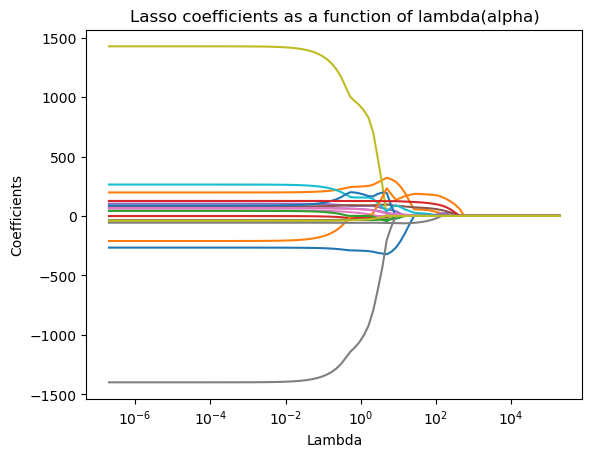

In [66]:
ax = plt.gca() 
ax.plot(alphas*2, coefs) 
ax.set_xscale('log') 
plt.axis('tight') 
plt.xlabel('Lambda') 
plt.ylabel('Coefficients') 
plt.title('Lasso coefficients as a function of lambda(alpha)'); 
plt.show()


In [67]:
 lassocv = LassoCV(alphas=None, cv=10, max_iter=100000)

In [68]:
 lassocv.fit(scaler.fit_transform(X_train), y_train)  

LassoCV(cv=10, max_iter=100000)

In [70]:
LassoCV(cv=10, max_iter=100000)

LassoCV(cv=10, max_iter=100000)

In [71]:
 lassocv.alpha_

27.50328326187841

In [72]:
 lasso.set_params(alpha=lassocv.alpha_)

Lasso(alpha=27.50328326187841, max_iter=100000)

In [73]:
 lasso.fit(scaler.fit_transform(X_train), y_train) 

Lasso(alpha=27.50328326187841, max_iter=100000)

In [74]:
mean_squared_error(y_test, lasso.predict(scaler.fit_transform(X_test)))

106183.71692611948

In [75]:
pd.Series(lasso.coef_, index=X.columns)  

AtBat            0.000000
Hits            50.246197
HmRun            0.000000
Runs             0.000000
RBI              0.000000
Walks           66.794424
Years            0.000000
CAtBat           0.000000
CHits            0.000000
CHmRun          19.441152
CRuns            0.000000
CRBI           181.336557
CWalks           0.000000
PutOuts        110.307327
Assists         -0.000000
Errors          -0.000000
League_N         0.000000
Division_W     -44.530872
NewLeague_N      0.000000
dtype: float64

In [76]:
pd.Series(lasso.coef_, index=X.columns)  

AtBat            0.000000
Hits            50.246197
HmRun            0.000000
Runs             0.000000
RBI              0.000000
Walks           66.794424
Years            0.000000
CAtBat           0.000000
CHits            0.000000
CHmRun          19.441152
CRuns            0.000000
CRBI           181.336557
CWalks           0.000000
PutOuts        110.307327
Assists         -0.000000
Errors          -0.000000
League_N         0.000000
Division_W     -44.530872
NewLeague_N      0.000000
dtype: float64

In [77]:
pd.Series(lasso.coef_[lasso.coef_ !=0], index=X.columns[lasso.coef_ !=0])

Hits           50.246197
Walks          66.794424
CHmRun         19.441152
CRBI          181.336557
PutOuts       110.307327
Division_W    -44.530872
dtype: float64

# Gaussian and Normalization Distribution

###### https://medium.com/@saurabhzodex/statistics-part-4-gaussian-and-non-gaussian-distribution-f03fcc1f1bc0